# Final Codes for Clustering Analysis

**Goal:** Identify skill groups. Explore the relationships between skill groups, salaries, job titles and seniority levels.

**Data:** `prepared_survey_data.csv` — 49,191 records with 83 binary skill indicators. `prepared_job_posting_ai.csv` — 1,213 AI job postings with 20 binary skill indicators.

## 1 · Cluster Developer Survey Records Based on Binary Skill Variables

### Packages and Dataaset Loading

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import matplotlib.patches as mpatches
import numpy as np
# Load the dataset
df = pd.read_csv('data/prepared_survey_data.csv')
print(f'Shape : {df.shape}')

Shape : (49191, 85)


### Explore Data

In [3]:
# Identify columns 
META_COLS  = ["DevType", "Industry"]
SKILL_COLS = df.columns[2:].tolist()
 
print(f"\n  Metadata cols  : {META_COLS}")
print(f"  Skill cols     : {len(SKILL_COLS)} features")
print(f"  Job role dist  :\n{df['DevType'].value_counts().head(10).to_string()}")


  Metadata cols  : ['DevType', 'Industry']
  Skill cols     : 83 features
  Job role dist  :
DevType
Developer, full-stack                            12351
Developer, back-end                               6453
Student                                           3008
Architect, software or solutions                  2684
Developer, front-end                              1974
Developer, desktop or enterprise applications     1919
Other (please specify):                           1825
Developer, mobile                                 1391
Developer, embedded applications or devices       1274
Academic researcher                               1131


In [4]:
# Data Cleaning & Preparation
df_clean = df.dropna(subset=['DevType']).copy()

# Select only the binary skill indicator columns (starting from index 2)
skill_cols = df_clean.columns[2:]
X = df_clean[skill_cols]

### Final KMeans Model
We explore different K values in the working codes, and determine the **final K value to be 6** for this dataset.

In [5]:
k_optimal = 6
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=617, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X)

In [12]:
# Cluster Profiling Logic
cluster_profiles = []

for i in range(k_optimal):
    cluster_data = df_clean[df_clean['Cluster'] == i]
    
    #skill frequency as a percentage
    skill_freq = cluster_data[skill_cols].mean().sort_values(ascending=False).head(10)
    
    #top job titles in this cluster
    top_titles = cluster_data['DevType'].value_counts().head(5)
    
    cluster_profiles.append({
        'Cluster': i,
        'Size': len(cluster_data),
        'Top Skills': skill_freq.to_dict(),
        'Top Titles': top_titles.to_dict()
    })


### Visualizations and Findings

In [7]:
# Visualization Preparation
summary_list = []
for p in cluster_profiles:
    for skill, freq in p['Top Skills'].items():
        summary_list.append({'Cluster': p['Cluster'], 'Name': skill, 'Value': freq})

df_summary = pd.DataFrame(summary_list)

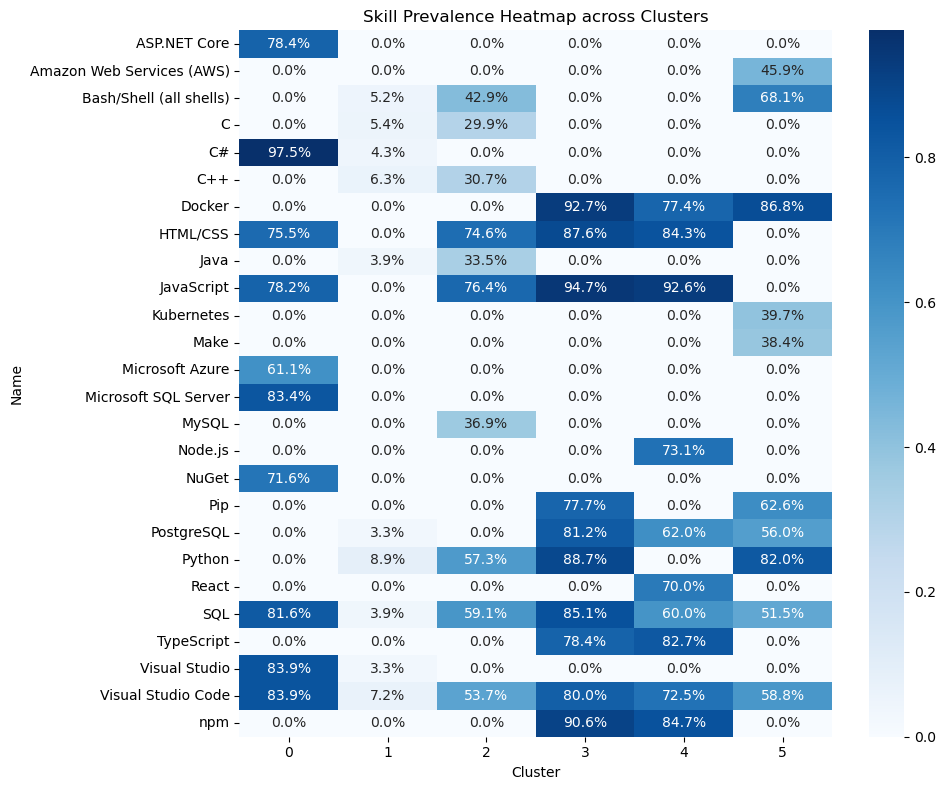

In [8]:
# VISUAL 1: Skill Prevalence Heatmap
skill_matrix = df_summary.pivot(index='Name', columns='Cluster', values='Value').fillna(0)
plt.figure(figsize=(10, 8))
sns.heatmap(skill_matrix, annot=True, cmap='Blues', fmt='.1%')
plt.title('Skill Prevalence Heatmap across Clusters')
plt.tight_layout()
plt.savefig('skill_prevalence_heatmap.png', transparent=True, dpi=300, bbox_inches='tight')

**Interpretation**: There are six distinct clusters whose skill prevalence indicates different technology ecosystems

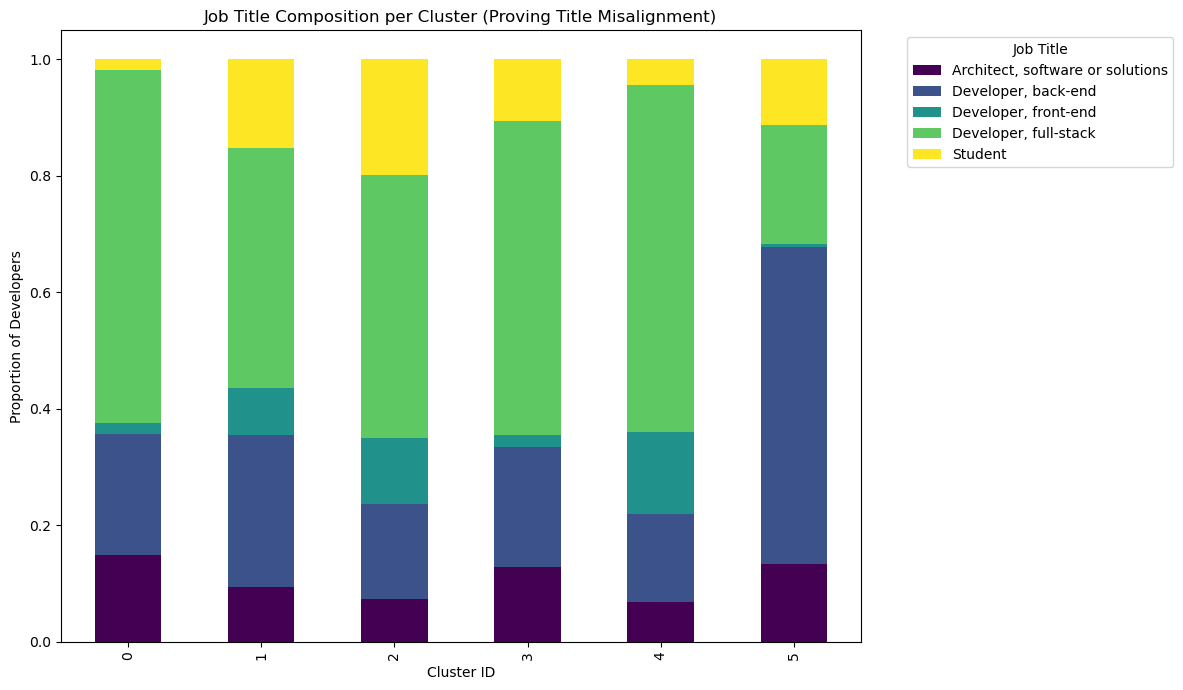

In [11]:
# VISUAL 2: Job Title Composition (Proving Title Misalignment)
top_titles_list = df_clean['DevType'].value_counts().head(5).index
df_filtered = df_clean[df_clean['DevType'].isin(top_titles_list)]
title_composition = pd.crosstab(df_filtered['Cluster'], df_filtered['DevType'], normalize='index')

title_composition.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Job Title Composition per Cluster (Proving Title Misalignment)')
plt.ylabel('Proportion of Developers')
plt.xlabel('Cluster ID')
plt.legend(title='Job Title', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('job_title_misalignment.png')

**Interpretation**: Generally, job titles are nearly identical across all clusters.
- Developer, full-stack (green) dominates every cluster, always the largest segment
- Developer, back-end (blue-grey) is consistently the second largest
- Developer, front-end (teal) appears at similar proportions across all clusters
- Architect (purple) and Student (yellow) appear in small but consistent shares

In [ ]:
# VISUAL 3: Radar Chart (Specialist vs Generalist) ---
radar_skills = [
    'Python',
    'Docker',
    'Bash/Shell (all shells)',
    'JavaScript',
    'SQL',
    'Visual Studio Code',
    'Amazon Web Services (AWS)',
]

cluster_means = df_clean.groupby('Cluster')[skill_cols].mean()
radar_data = cluster_means[radar_skills].loc[[0, 1]]

categories = radar_skills
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

# Cluster 0
values_c0 = radar_data.loc[0].values.flatten().tolist()
values_c0 += values_c0[:1]
ax.plot(angles, values_c0, linewidth=2, label='Cluster 0 (Specialist)')
ax.fill(angles, values_c0, alpha=0.1)

# Cluster 1
values_c1 = radar_data.loc[1].values.flatten().tolist()
values_c1 += values_c1[:1]
ax.plot(angles, values_c1, linewidth=2, label='Cluster 1 (Generalist)')
ax.fill(angles, values_c1, alpha=0.1)

plt.xticks(angles[:-1], categories)
plt.title('Specialist (C0) vs. Generalist (C1)')
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.tight_layout()
plt.savefig('specialist_vs_generalist_radar.png')

**Blue-shape Cluster 0 (Specialist)**
Large and asymmetric: dominant on some axes, near-zero on others. This is the visual signature of a specialist.

**Orange-shape Cluster 1 (Generalist)**
Smaller but rounder: moderate across multiple axes without extreme highs or lows. This is the visual signature of a generalist.

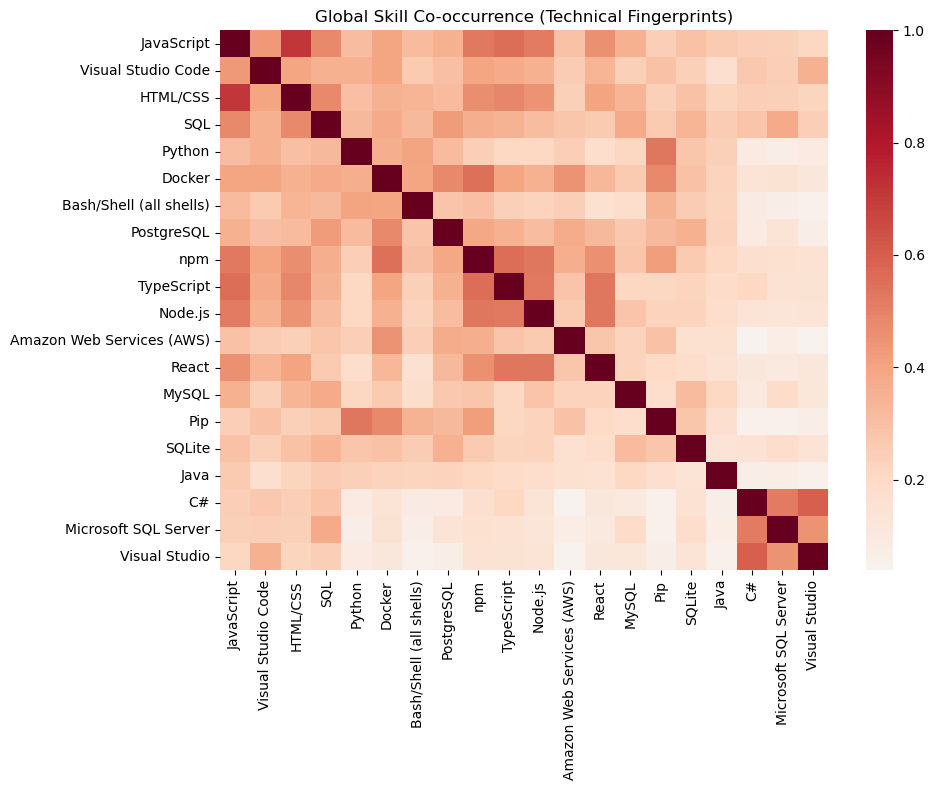

In [10]:
# VISUAL 4: Global Skill Correlation (The Fingerprints) ---
top_20_skills = df_clean[skill_cols].mean().sort_values(ascending=False).head(20).index
skill_corr = df_clean[top_20_skills].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(skill_corr, cmap='RdBu_r', center=0)
plt.title('Global Skill Co-occurrence (Technical Fingerprints)')
plt.tight_layout()
plt.savefig('skill_correlation_fingerprints.png')

**Two Distinct Ecosystem Blocks Are Visible.** The most important structural feature is the block pattern — not individual cells but the overall shape.
- **Block 1: Top-left (rows/cols 1–16): Open-Source / Web / Cloud Stack.**
JavaScript, VS Code, HTML/CSS, SQL, Python, Docker, Bash/Shell, PostgreSQL, npm, TypeScript, Node.js, AWS, React, MySQL, Pip, SQLite all co-occur with each other at moderate-to-high rates — the large warm pink region. These skills form one interconnected ecosystem.
- **Block 2: Bottom-right (rows/cols 18–20): Microsoft Enterprise Stack.**
C#, Microsoft SQL Server, and Visual Studio form a tight dark cluster, co-occurring strongly with each other but showing near-zero values with almost everything in Block 1.
- The white gap between the two blocks is the most important visual — it confirms the two ecosystems are mutually exclusive in practice.

## 2 · Cluster AI Job Postings Based on Binary Skill Variables

From previous analysis, we know that job titles are nearly identical across all clusters. In this analysis, we are wondering **whether there exist certain assocations between seniority and clustered skill groups**.

### Packages and Dataset Loading

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# ── Aesthetic defaults ────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.05)
PALETTE   = ['#4E79A7', '#F28E2B', '#59A14F', '#E15759', '#B07AA1']
EXP_ORDER = ['Junior/Entry', 'Mid/Standard', 'Senior']
RANDOM    = 617
np.random.seed(RANDOM)

In [22]:
DATA_PATH = 'data/prepared_job_posting_ai.csv'  
df = pd.read_csv(DATA_PATH)
print(f'Shape : {df.shape}')

Shape : (1213, 29)


### Explore Data

In [29]:
# Identify skill columns (all binary 0/1)
SKILL_COLS = [
    'Machine Learning', 'Deep Learning', 'NLP', 'Computer Vision',
    'Generative AI', 'Statistics', 'Python', 'SQL', 'C++', 'Java',
    'PyTorch', 'TensorFlow', 'Scikit-Learn', 'Cloud Computing', 'Big Data',
    'MLOps', 'Data Visualization', 'Communication', 'Project Management',
    'Problem Solving'
]

META_COLS = ['Post_Date', 'Company', 'Title', 'Field', 'Seniority_Level',
             'Salary', 'Post_Year', 'Post_Month']

print(f'Skill columns  : {len(SKILL_COLS)}')
print(f'Missing values : {df[SKILL_COLS].isnull().sum().sum()} (in skill matrix)')
print()
print('Field distribution (top 8):')
print(df['Field'].value_counts().head(8).to_string())

Skill columns  : 20
Missing values : 0 (in skill matrix)

Field distribution (top 8):
Field
IT                             960
Engineering                    121
Scientific & QA                 49
Sales                           16
Accounting & Finance            12
PR, Advertising & Marketing     11
Trade & Construction             9
Consultancy                      7


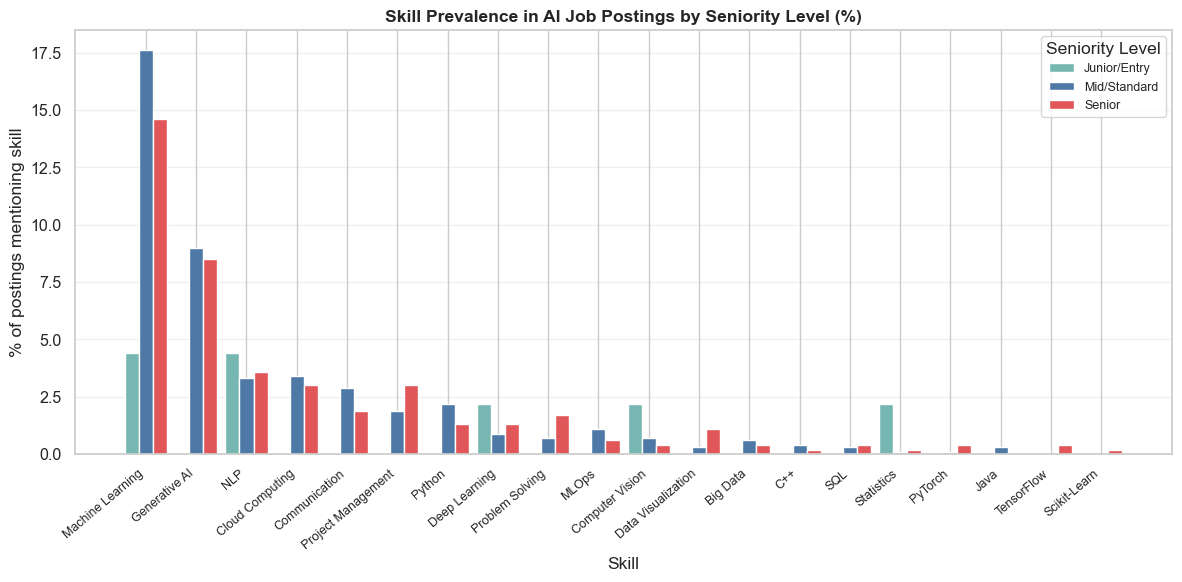

In [30]:
# Skill prevalence by seniority level
SEN_ORDER = ['Junior/Entry', 'Mid/Standard', 'Senior']
SEN_PAL   = {'Junior/Entry': '#76B7B2', 'Mid/Standard': '#4E79A7', 'Senior': '#E15759'}

# Overall prevalence (for sorting order)
skill_freq = (df[SKILL_COLS].mean() * 100).sort_values(ascending=False).round(1)

# Prevalence per seniority level
skill_by_sen = (
    df.groupby('Seniority_Level')[SKILL_COLS].mean() * 100
).round(1)

fig, ax = plt.subplots(figsize=(12, 6))

x      = np.arange(len(skill_freq))
width  = 0.28

for i, sen in enumerate(SEN_ORDER):
    vals = skill_by_sen.loc[sen, skill_freq.index].values   # match overall sort order
    bars = ax.bar(
        x + (i - 1) * width, vals, width,
        label=sen, color=SEN_PAL[sen], edgecolor='white'
    )

ax.set_title('Skill Prevalence in AI Job Postings by Seniority Level (%)',
             fontweight='bold')
ax.set_xlabel('Skill')
ax.set_ylabel('% of postings mentioning skill')
ax.set_xticks(x)
ax.set_xticklabels(skill_freq.index, rotation=40, ha='right', fontsize=9)
ax.legend(title='Seniority Level', fontsize=9)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig0_skill_prevalence.png', dpi=150,
            bbox_inches='tight', transparent=True)
plt.show()

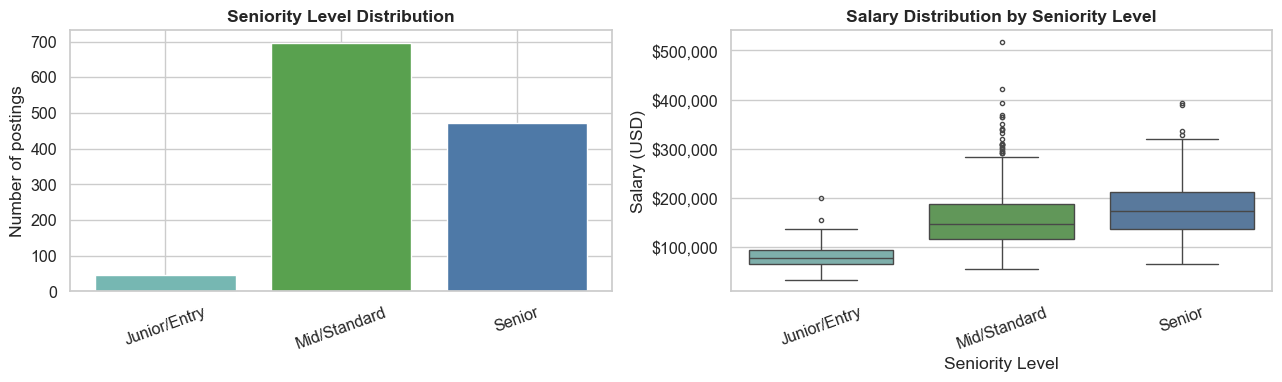

In [31]:
# Salary by seniority level
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Seniority_Level distribution
counts = df['Seniority_Level'].value_counts().reindex(EXP_ORDER, fill_value=0)
axes[0].bar(counts.index, counts.values,
            color=['#76B7B2', '#59A14F', '#4E79A7'])
axes[0].set_title('Seniority Level Distribution', fontweight='bold')
axes[0].set_ylabel('Number of postings')
axes[0].tick_params(axis='x', rotation=20)

# Salary box by Seniority_Level
order_present = [l for l in EXP_ORDER if l in df['Seniority_Level'].unique()]
sns.boxplot(data=df, x='Seniority_Level', y='Salary', order=order_present,
            palette=['#76B7B2', '#59A14F', '#4E79A7'],
            ax=axes[1], fliersize=3)
axes[1].set_title('Salary Distribution by Seniority Level', fontweight='bold')
axes[1].set_xlabel('Seniority Level')
axes[1].set_ylabel('Salary (USD)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('fig1_seniority_level_overview.png', dpi=150, bbox_inches='tight')
plt.show()

### Final Kmeans Model
We run different K values in the working codes, and determine the **final K value to be 3** for this dataset.

In [35]:
# Train the Kmeans Model with the Final K Value
X = df[SKILL_COLS].values.astype(float)
K_FINAL = 3
km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM, n_init=10, max_iter=300)
km_final.fit(X)

df['Cluster'] = km_final.labels_
centroids     = km_final.cluster_centers_   # shape (K, n_skills)

CLUSTER_NAMES = {
    0: 'Generative AI Specialist',
    1: 'Generalist / Operational',
    2: 'Core ML Engineer'
}

df['Cluster_Name'] = df['Cluster'].map(CLUSTER_NAMES)

print('Cluster assignment summary:')
print(df.groupby(['Cluster', 'Cluster_Name']).size().reset_index(name='n').to_string(index=False))

Cluster assignment summary:
 Cluster             Cluster_Name   n
       0 Generative AI Specialist 103
       1 Generalist / Operational 951
       2         Core ML Engineer 159


In [36]:
# Inspect top skills per cluster to assign semantic names
TOP_N = 5

print('Top skills per cluster (centroid values):')
print('-' * 60)
for c in range(K_FINAL):
    top_idx    = np.argsort(centroids[c])[::-1][:TOP_N]
    top_skills = [(SKILL_COLS[i], round(centroids[c][i], 3)) for i in top_idx
                  if centroids[c][i] > 0]
    n = (df['Cluster'] == c).sum()
    print(f'Cluster {c} (n={n:,}) → {top_skills}')

Top skills per cluster (centroid values):
------------------------------------------------------------
Cluster 0 (n=103) → [('Generative AI', np.float64(1.0)), ('Machine Learning', np.float64(0.34)), ('NLP', np.float64(0.136)), ('Cloud Computing', np.float64(0.087)), ('Python', np.float64(0.058))]
Cluster 1 (n=951) → [('Cloud Computing', np.float64(0.023)), ('Communication', np.float64(0.022)), ('Project Management', np.float64(0.02)), ('NLP', np.float64(0.015)), ('Problem Solving', np.float64(0.012))]
Cluster 2 (n=159) → [('Machine Learning', np.float64(1.0)), ('NLP', np.float64(0.088)), ('Cloud Computing', np.float64(0.044)), ('Project Management', np.float64(0.044)), ('Python', np.float64(0.038))]


### Visualizations
To understand the clustering results.

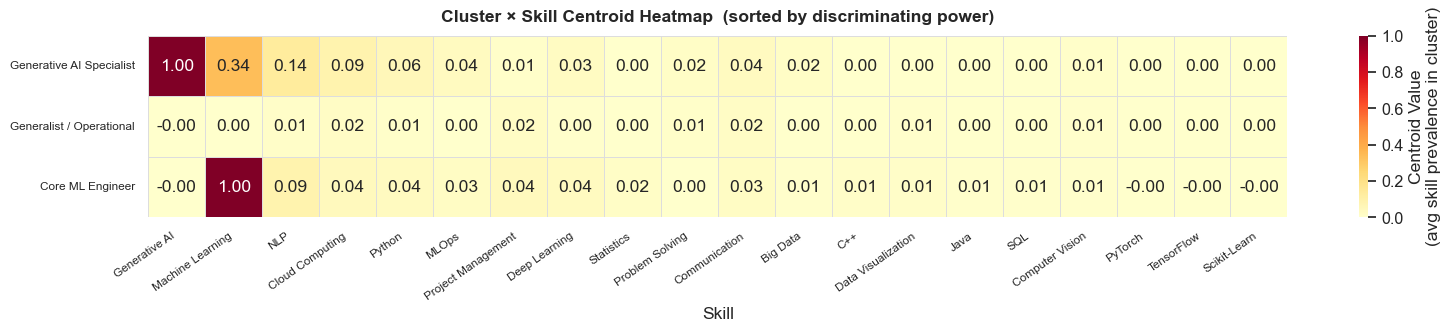

In [37]:
# VISUAL 1: Centroid heatmap
centroid_df = pd.DataFrame(
    centroids,
    index=[CLUSTER_NAMES[c] for c in range(K_FINAL)],
    columns=SKILL_COLS
)

centroid_df = centroid_df[centroid_df.std(axis=0).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(16, 3.5))
sns.heatmap(
    centroid_df, ax=ax, cmap='YlOrRd', annot=True, fmt='.2f',
    linewidths=0.4, linecolor='#dddddd',
    cbar_kws={'label': 'Centroid Value\n(avg skill prevalence in cluster)'}
)
ax.set_title('Cluster × Skill Centroid Heatmap  (sorted by discriminating power)',
             fontweight='bold', pad=10)
ax.set_xlabel('Skill')
ax.set_ylabel('')
plt.xticks(rotation=35, ha='right', fontsize=8.5)
plt.yticks(rotation=0, fontsize=8.5)
plt.tight_layout()
plt.savefig('fig3_centroid_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

- **Cluster 1** has an obvious focus on Gen AI skills.
- **Cluster 2** has no emphasis on any related skills.
- **Cluster 3** focuses on ML skills.

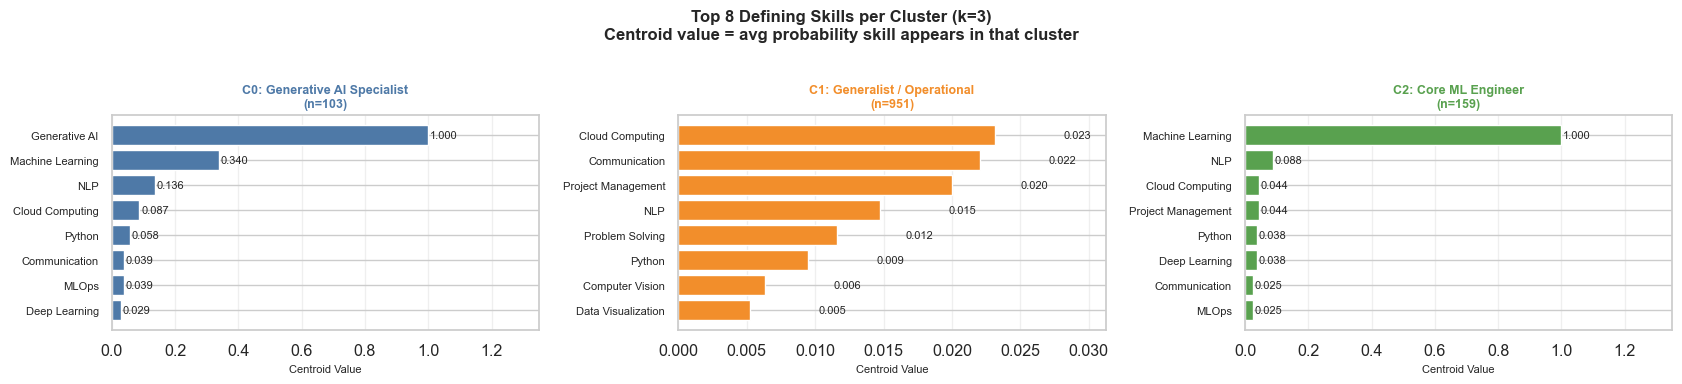

In [39]:
# VISUAL 2: Top skills per cluster (bar chart grid)
TOP_BAR = 8
ncols   = 3
nrows   = (K_FINAL + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(17, nrows * 3.8))
axes = axes.flatten()

for c in range(K_FINAL):
    ax      = axes[c]
    top_idx = np.argsort(centroids[c])[::-1][:TOP_BAR]
    skills  = [SKILL_COLS[i] for i in top_idx]
    values  = [centroids[c][i] for i in top_idx]

    bars = ax.barh(skills[::-1], values[::-1], color=PALETTE[c], edgecolor='white')
    for bar, val in zip(bars, values[::-1]):
        if val > 0:
            ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                    f'{val:.3f}', va='center', fontsize=8)

    n = (df['Cluster'] == c).sum()
    ax.set_title(f'C{c}: {CLUSTER_NAMES[c]}\n(n={n:,})',
                 fontsize=9, fontweight='bold', color=PALETTE[c])
    ax.set_xlabel('Centroid Value', fontsize=8)
    ax.set_xlim(0, max(values) * 1.35 if max(values) > 0 else 0.1)
    ax.grid(True, axis='x', alpha=0.3)
    ax.tick_params(axis='y', labelsize=8)

for i in range(K_FINAL, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(f'Top {TOP_BAR} Defining Skills per Cluster (k={K_FINAL})\n'
             'Centroid value = avg probability skill appears in that cluster',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig4_top_skills_per_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

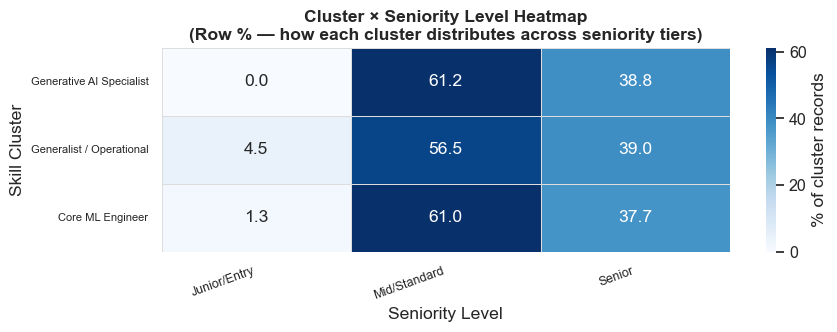

In [41]:
# VISUAL 3: Heatmap: Cluster × Seniority_Level
ct_pct = (
    pd.crosstab(df['Cluster_Name'], df['Seniority_Level'], normalize='index') * 100
).round(1).reindex(columns=EXP_ORDER, fill_value=0)

# Sort rows by cluster id
ct_pct = ct_pct.loc[[CLUSTER_NAMES[c] for c in range(K_FINAL)]]

fig, ax = plt.subplots(figsize=(9, 3.5))
sns.heatmap(
    ct_pct, ax=ax, cmap='Blues', annot=True, fmt='.1f',
    linewidths=0.5, linecolor='#dddddd',
    cbar_kws={'label': '% of cluster records'}
)
ax.set_title('Cluster × Seniority Level Heatmap\n'
             '(Row % — how each cluster distributes across seniority tiers)',
             fontweight='bold')
ax.set_xlabel('Seniority Level')
ax.set_ylabel('Skill Cluster')
plt.xticks(rotation=20, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('fig6_cluster_seniority_level_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Mid/ Standard Level** holds the dominant position acroos three clusters. The percentage is highest in the Gen AI Specialist cluster.

Mean Salary by Cluster × Seniority Level:
Seniority_Level          Junior/Entry Mid/Standard    Senior
Cluster_Name                                                
Generative AI Specialist          N/A     $166,485  $172,124
Generalist / Operational      $82,676     $152,920  $174,588
Core ML Engineer              $77,536     $172,646  $198,963


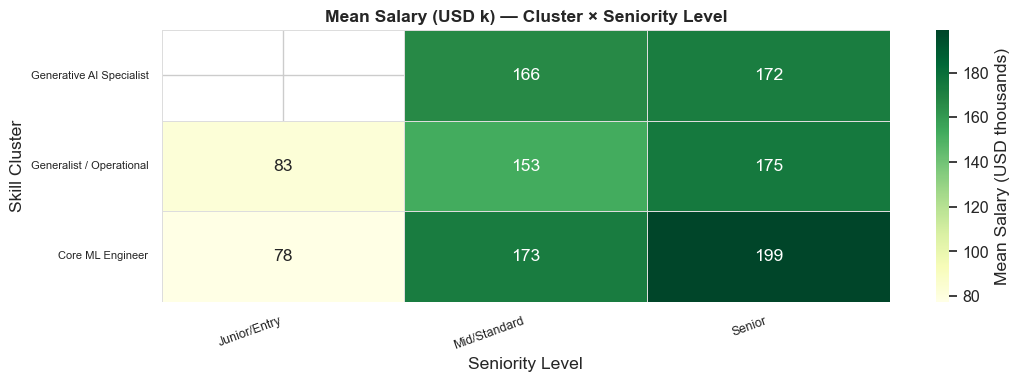

In [42]:
# VISUAL 4: Salary by Cluster × Seniority_Level
sal_pivot = (
    df.groupby(['Cluster_Name', 'Seniority_Level'])['Salary']
    .mean()
    .unstack()
    .reindex(columns=EXP_ORDER)
    .reindex([CLUSTER_NAMES[c] for c in range(K_FINAL)])
)

print('Mean Salary by Cluster × Seniority Level:')
print(sal_pivot.map(lambda x: f'${x:,.0f}' if not pd.isna(x) else 'N/A').to_string())

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    sal_pivot / 1000, ax=ax, cmap='YlGn', annot=True, fmt='.0f',
    linewidths=0.5, linecolor='#dddddd',
    cbar_kws={'label': 'Mean Salary (USD thousands)'}
)
ax.set_title('Mean Salary (USD k) — Cluster × Seniority Level',
             fontweight='bold')
ax.set_xlabel('Seniority Level')
ax.set_ylabel('Skill Cluster')
plt.xticks(rotation=20, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('fig7_salary_cluster_seniority_level.png', dpi=150, bbox_inches='tight')
plt.show()

**ML core** commands the highest salaries across clusters for mid and senior levels.

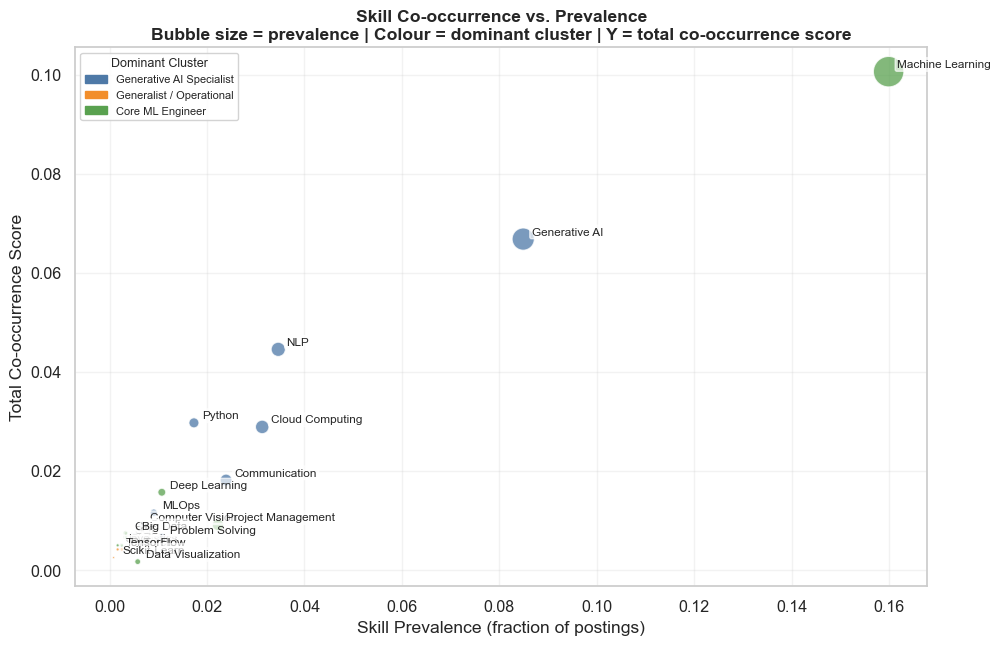

<Figure size 1000x600 with 0 Axes>

In [44]:
# VISUAL 5: Skill Co-occurrence VS. Skill Prevalence
# Skills with any signal (prevalence > 0)

active_mask  = X.mean(axis=0) > 0
active_skills = [s for s, m in zip(SKILL_COLS, active_mask) if m]
X_active      = X[:, active_mask]

co_matrix = (X_active.T @ X_active) / len(X_active)   # joint probability
np.fill_diagonal(co_matrix, 0)

prevalence   = X_active.mean(axis=0)
co_sum       = co_matrix.sum(axis=1)
dom_cluster  = np.argmax(centroids[:, active_mask], axis=0)

fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(
    prevalence, co_sum,
    s=prevalence * 3000,
    c=[PALETTE[d % len(PALETTE)] for d in dom_cluster],
    alpha=0.75, edgecolors='white', linewidths=0.8
)
for i, name in enumerate(active_skills):
    ax.annotate(name, (prevalence[i], co_sum[i]),
                textcoords='offset points', xytext=(6, 3), fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.65))

legend_handles = [
    mpatches.Patch(color=PALETTE[c], label=CLUSTER_NAMES[c])
    for c in range(K_FINAL)
]
ax.legend(handles=legend_handles, title='Dominant Cluster', fontsize=8,
          title_fontsize=9, loc='upper left', framealpha=0.85)
ax.set_title('Skill Co-occurrence vs. Prevalence\n'
             'Bubble size = prevalence | Colour = dominant cluster | '
             'Y = total co-occurrence score',
             fontweight='bold')
ax.set_xlabel('Skill Prevalence (fraction of postings)')
ax.set_ylabel('Total Co-occurrence Score')
ax.grid(True, alpha=0.25)
plt.figure(figsize=(10, 6))
plt.tight_layout()
plt.savefig('fig10_cooccurrence_bubble.png', dpi=150, bbox_inches='tight')
plt.show()

**A positive correlation** exists between skill prevalence and skill co-occurrence.